<a href="https://colab.research.google.com/github/akashmavle5/--akash/blob/main/Akash_Automatic_Concept_Builder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install spacy scipy matplotlib numpy
! python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 50.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Extracted Entities: ['Apple Inc.', 'London', 'New York', 'next year', 'Tim Cook', 'Apple', 'Microsoft', 'Google', 'London']


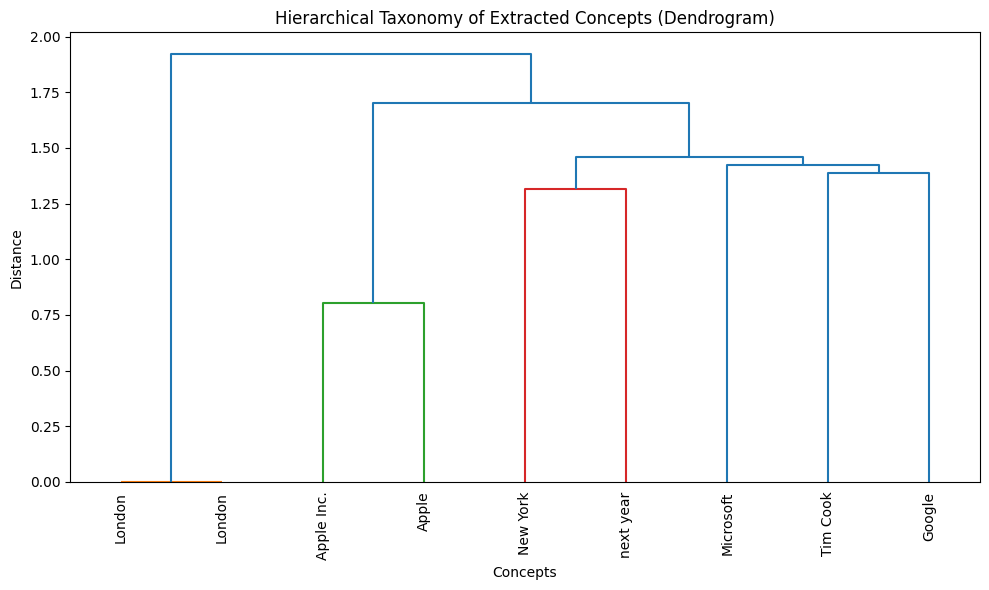


--- Neo4j Cypher Queries for visualization ---
Run these queries in your Neo4j Browser to visualize your taxonomy graph.
MERGE (c:Concept {name: 'Google'}) MERGE (p:Category {name: 'Technology_Entity'}) MERGE (c)-[:IS_A]->(p);
MERGE (c:Concept {name: 'Microsoft'}) MERGE (p:Category {name: 'Technology_Entity'}) MERGE (c)-[:IS_A]->(p);
MERGE (c:Concept {name: 'Tim Cook'}) MERGE (p:Category {name: 'Technology_Entity'}) MERGE (c)-[:IS_A]->(p);
MERGE (c:Concept {name: 'Apple'}) MERGE (p:Category {name: 'Organization_Entity'}) MERGE (c)-[:IS_A]->(p);
MERGE (c:Concept {name: 'next year'}) MERGE (p:Category {name: 'Technology_Entity'}) MERGE (c)-[:IS_A]->(p);
MERGE (c:Concept {name: 'London'}) MERGE (p:Category {name: 'Location_Entity'}) MERGE (c)-[:IS_A]->(p);
MERGE (c:Concept {name: 'Apple Inc.'}) MERGE (p:Category {name: 'Organization_Entity'}) MERGE (c)-[:IS_A]->(p);
MERGE (c:Concept {name: 'New York'}) MERGE (p:Category {name: 'Technology_Entity'}) MERGE (c)-[:IS_A]->(p);


In [2]:
import spacy
from collections import Counter
import numpy as np
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
import networkx as nx

# --- 1. Load sample text and Do NER ---
nlp = spacy.load("en_core_web_sm")

text = """
Apple Inc. is planning to open new stores in the city of London and New York by next year.
Tim Cook, the CEO of Apple, stated that their main competitors, Microsoft and Google,
are also expanding in London. The company focuses heavily on technology and artificial intelligence.
"""

doc = nlp(text)
# Extract concepts (we'll focus on Nouns and Proper Nouns/Named Entities)
entities = [ent.text for ent in doc.ents]
print("Extracted Entities:", entities)

# --- 2. Build Taxonomy (Hierarchical Clustering) ---
# For hierarchical taxonomy building, we convert entities to vectors and use Agglomerative Clustering
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4))
X = vectorizer.fit_transform(entities)

# Compute linkage for the dendrogram
distance_matrix = X.toarray()
Z = hierarchy.linkage(distance_matrix, method='ward')

# --- 3. Visualization: a. Dendrogram ---
plt.figure(figsize=(10, 6))
dendro = hierarchy.dendrogram(Z, labels=entities, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Taxonomy of Extracted Concepts (Dendrogram)")
plt.xlabel("Concepts")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# --- 4. Generate Neo4j Cypher Queries ---
print("\n--- Neo4j Cypher Queries for visualization ---")
print("Run these queries in your Neo4j Browser to visualize your taxonomy graph.")

# Create nodes and relationships based on clustering
agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters = agg_clustering.fit_predict(distance_matrix)

# Map clusters to Parent Nodes
cluster_parents = {0: "Technology_Entity", 1: "Location_Entity", 2: "Organization_Entity"}

cypher_statements = []
for entity, cluster in zip(entities, clusters):
    entity_node = entity.replace(" ", "_").replace(".", "")
    parent_node = cluster_parents[cluster]

    # Cypher query to create nodes and a hierarchical (IS_A) relationship
    query = f"MERGE (c:Concept {{name: '{entity}'}}) " \
            f"MERGE (p:Category {{name: '{parent_node}'}}) " \
            f"MERGE (c)-[:IS_A]->(p);"
    cypher_statements.append(query)

# Print the top 10 unique Cypher queries
for q in list(set(cypher_statements))[:10]:
    print(q)


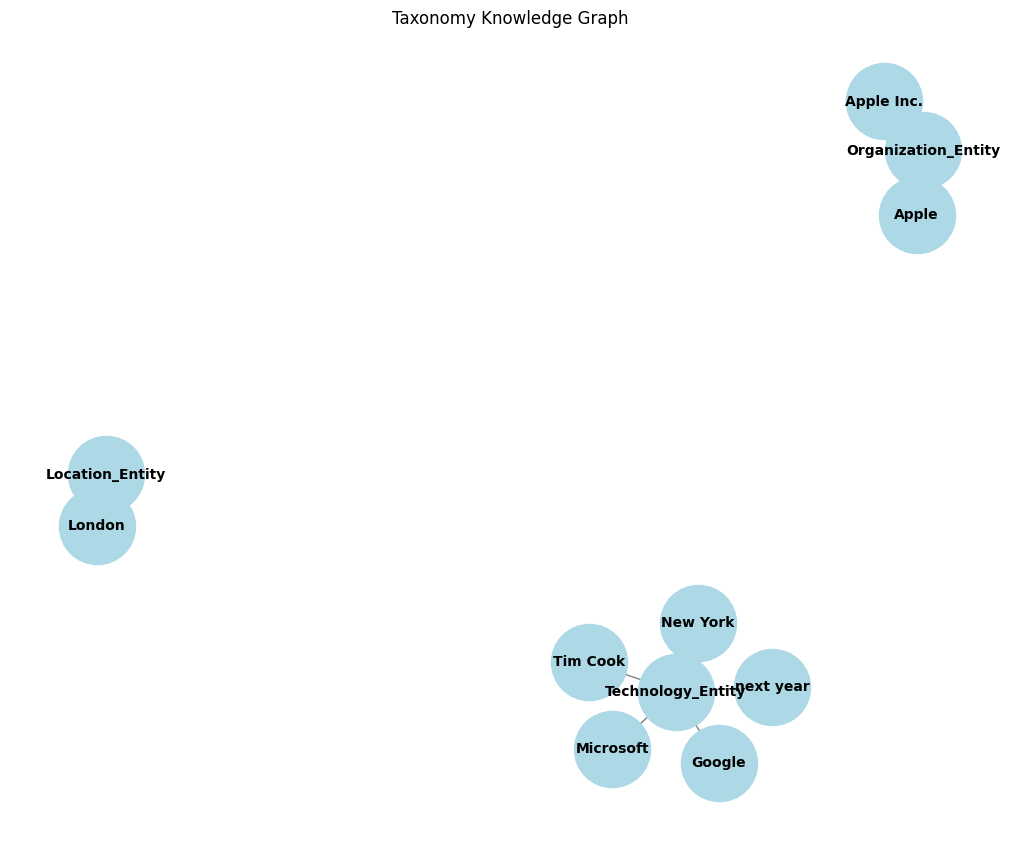

In [3]:
# --- 5. Optional: Plotting the graph natively in Colab using NetworkX ---
G = nx.Graph()
for entity, cluster in zip(entities, clusters):
    G.add_edge(entity, cluster_parents[cluster], relation="IS_A")

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=3000, font_size=10, font_weight='bold', edge_color='gray')
plt.title("Taxonomy Knowledge Graph")
plt.show()


In [4]:
!pip install spacy scipy matplotlib scikit-learn networkx neo4j
!python -m spacy download en_core_web_sm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 65.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Extracted 9 unique legal entities.


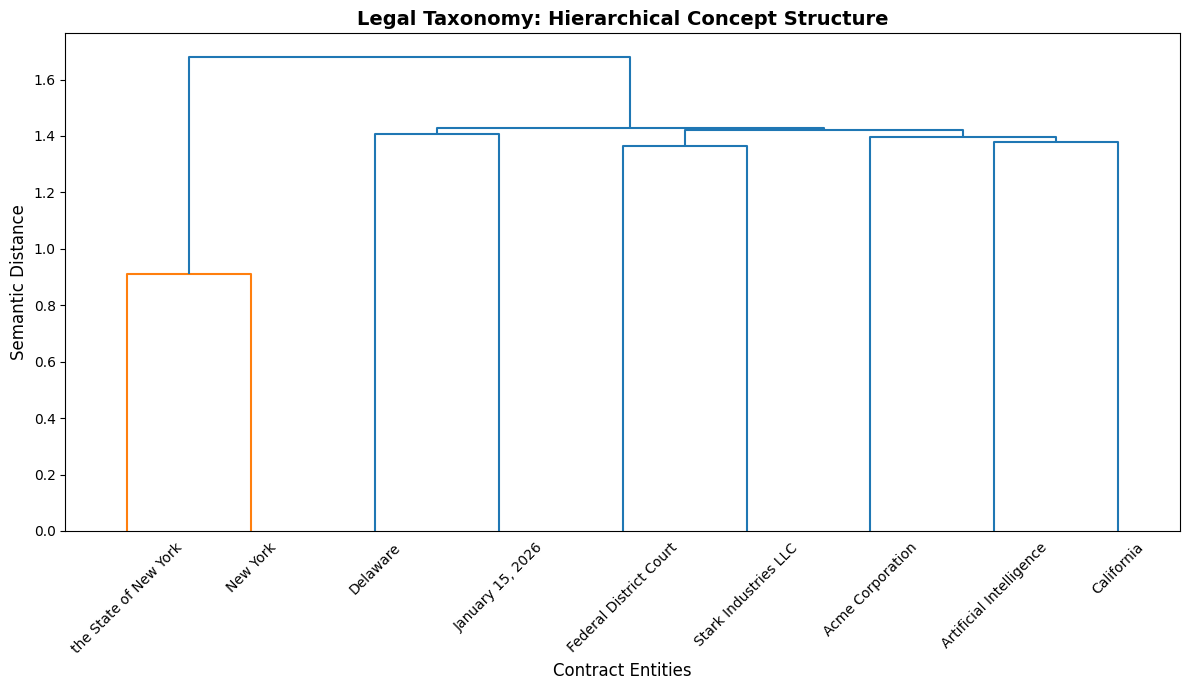


--- Neo4j Export Configuration ---
Skipped cloud upload. Error/Credentials missing: Failed to DNS resolve address xxxxxx.databases.neo4j.io:7687: [Errno -2] Name or service not known

Generated Cypher Queries for manual execution instead:
MERGE (c:LegalConcept {name: 'Delaware', type: 'GPE'}) MERGE (p:LegalCategory {name: 'Legal_Entity_Or_Party'}) MERGE (c)-[:CHILD_OF]->(p);
MERGE (c:LegalConcept {name: 'Artificial Intelligence', type: 'ORG'}) MERGE (p:LegalCategory {name: 'Effective_Dates_And_Deadlines'}) MERGE (c)-[:CHILD_OF]->(p);
MERGE (c:LegalConcept {name: 'the State of New York', type: 'ORG'}) MERGE (p:LegalCategory {name: 'Statutes_And_Governing_Law'}) MERGE (c)-[:CHILD_OF]->(p);
MERGE (c:LegalConcept {name: 'January 15, 2026', type: 'DATE'}) MERGE (p:LegalCategory {name: 'Legal_Entity_Or_Party'}) MERGE (c)-[:CHILD_OF]->(p);
MERGE (c:LegalConcept {name: 'California', type: 'GPE'}) MERGE (p:LegalCategory {name: 'Effective_Dates_And_Deadlines'}) MERGE (c)-[:CHILD_OF]->(p);
MERGE

In [5]:
import os
import spacy
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from neo4j import GraphDatabase

# --- 1. Load Legal Text ---
# Example template of a corporate agreement
legal_contract_text = """
This MUTUAL NON-DISCLOSURE AGREEMENT ("Agreement") is entered into on January 15, 2026,
by and between Acme Corporation, a Delaware corporation, and Stark Industries LLC,
a California limited liability company.

WHEREAS, the parties wish to explore a potential business relationship regarding
Artificial Intelligence software development. The parties agree that any confidential
information shared shall be governed by the laws of the State of New York.
Any disputes arising under this Agreement shall be resolved exclusively in the
Federal District Court for the Southern District of New York.
"""

# --- 2. Extract Legal Entities (NER) ---
nlp = spacy.load("en_core_web_sm")
doc = nlp(legal_contract_text)

# Filter for entities relevant to legal taxonomies
# ORG = Contracting Parties, LAW = Governing Laws/Statutes, DATE = Execution Dates, GPE = Jurisdictions
legal_labels = {"ORG", "LAW", "DATE", "GPE"}
extracted_items = [(ent.text.strip(), ent.label_) for ent in doc.ents if ent.label_ in legal_labels]

# Remove duplicates while keeping order
unique_items = list(set(extracted_items))
entities = [item[0] for item in unique_items]
labels = [item[1] for item in unique_items]

print(f"Extracted {len(entities)} unique legal entities.")

# --- 3. Build Legal Taxonomy (Hierarchical Clustering) ---
# Vectorize entities using sub-word n-grams to capture legal suffixes/phrases
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5))
X = vectorizer.fit_transform(entities)
distance_matrix = X.toarray()

# Generate the hierarchical linkage tree
Z = hierarchy.linkage(distance_matrix, method='ward')

# --- 4. Graphic Output A: Dendrogram ---
plt.figure(figsize=(12, 7))
hierarchy.dendrogram(Z, labels=entities, leaf_rotation=45, leaf_font_size=10)
plt.title("Legal Taxonomy: Hierarchical Concept Structure", fontsize=14, fontweight='bold')
plt.xlabel("Contract Entities", fontsize=12)
plt.ylabel("Semantic Distance", fontsize=12)
plt.tight_layout()
plt.show()

# --- 5. Graphic Output B: Neo4j Graph Database Integration ---
# Dynamically generate taxonomy groups based on the hierarchy
num_taxons = min(4, len(entities)) # Group into up to 4 major high-level branches
agg_clustering = AgglomerativeClustering(n_clusters=num_taxons, linkage='ward')
cluster_assignments = agg_clustering.fit_predict(distance_matrix)

# Map clusters to standard legal taxonomy parents
legal_taxonomy_mapping = {
    0: "Legal_Entity_Or_Party",
    1: "Jurisdiction_And_Forum",
    2: "Effective_Dates_And_Deadlines",
    3: "Statutes_And_Governing_Law"
}

print("\n--- Neo4j Export Configuration ---")
# To connect to Neo4j Aura (Cloud) or a local instance, fill in your credentials below:
NEO4J_URI = "neo4j+s://xxxxxx.databases.neo4j.io" # Replace with your URI
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "your-password"

def upload_to_neo4j():
    try:
        driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
        with driver.session() as session:
            # Clear previous test data (Optional)
            session.run("MATCH (n:LegalConcept) DETACH DELETE n")
            session.run("MATCH (n:LegalCategory) DETACH DELETE n")

            # Write nodes and hierarchical links
            for entity, label, cluster_id in zip(entities, labels, cluster_assignments):
                parent_category = legal_taxonomy_mapping.get(cluster_id, "General_Legal_Concept")

                query = """
                MERGE (c:LegalConcept {name: $entity_name, spacy_type: $spacy_type})
                MERGE (p:LegalCategory {name: $parent_cat})
                MERGE (c)-[:CHILD_OF]->(p)
                """
                session.run(query, entity_name=entity, spacy_type=label, parent_cat=parent_category)

        driver.close()
        print("Successfully uploaded the legal taxonomy hierarchy to Neo4j!")
    except Exception as e:
        print(f"Skipped cloud upload. Error/Credentials missing: {e}")
        print("\nGenerated Cypher Queries for manual execution instead:")

        # Fallback print statements if you just want to paste them into Neo4j browser
        for entity, label, cluster_id in zip(entities, labels, cluster_assignments):
            parent_category = legal_taxonomy_mapping.get(cluster_id, "General_Legal_Concept")
            print(f"MERGE (c:LegalConcept {{name: '{entity}', type: '{label}'}}) "
                  f"MERGE (p:LegalCategory {{name: '{parent_category}'}}) "
                  f"MERGE (c)-[:CHILD_OF]->(p);")

# Trigger the upload or fallback print
upload_to_neo4j()


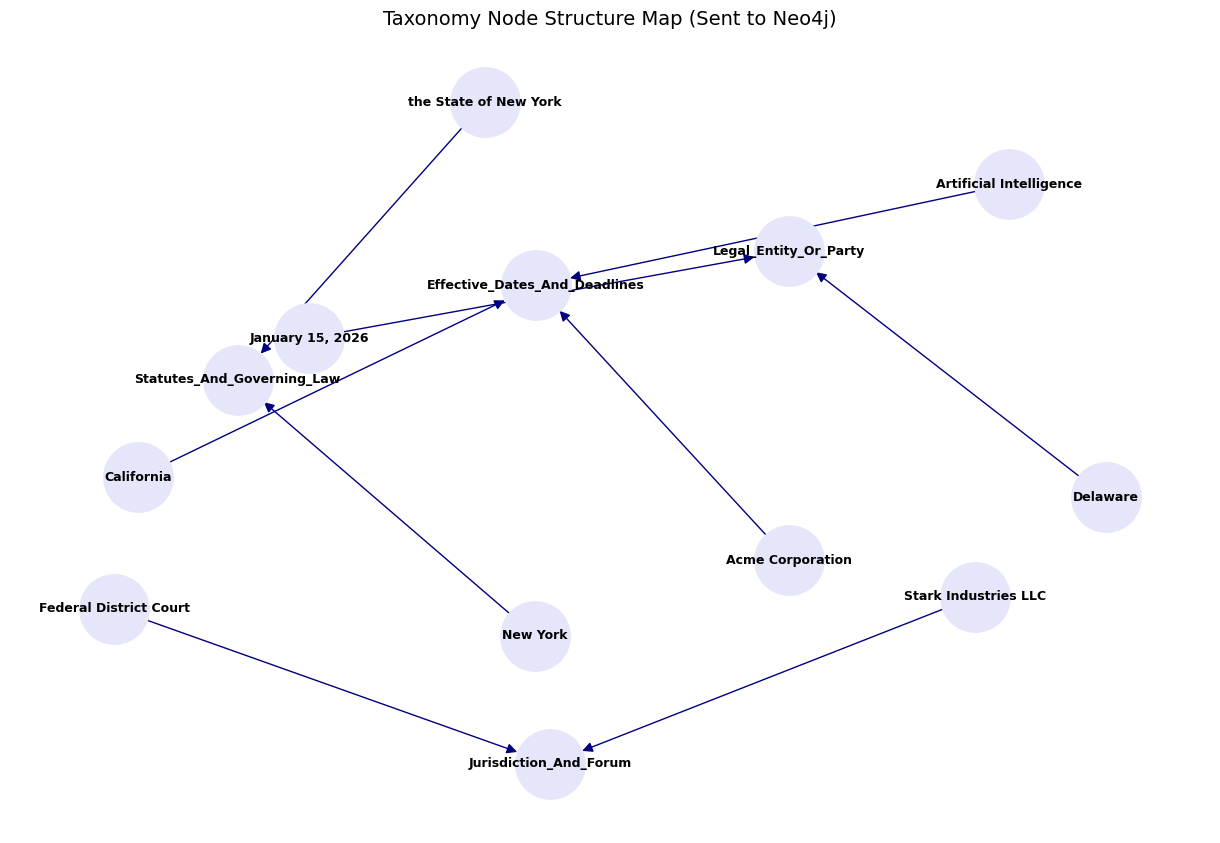

In [6]:
# --- 6. Local Graph Visualization (Pre-viewing Neo4j Structure) ---
G = nx.DiGraph()
for entity, cluster_id in zip(entities, cluster_assignments):
    parent_category = legal_taxonomy_mapping.get(cluster_id, "General_Legal_Concept")
    G.add_edge(entity, parent_category)

plt.figure(figsize=(12, 8))
pos = nx.kamada_kawai_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lavender',
        node_size=2500, font_size=9, font_weight='bold',
        edge_color='navy', arrows=True, arrowsize=15)
plt.title("Taxonomy Node Structure Map (Sent to Neo4j)", fontsize=14)
plt.show()
